In [2]:
import pandas as pd

# thay 'ten_file.csv' bằng tên file thật bạn vừa tải lên
df = pd.read_csv("HoaBinh_convert.csv")

# xem kích thước, các cột
print(df.shape)
print(df.columns)


(22176, 10)
Index(['time', 'temperature_2m (°C)', 'relative_humidity_2m (%)',
       'precipitation (mm)', 'wind_speed_10m (km/h)', 'cloud_cover (%)',
       'surface_pressure (hPa)', 'et0_fao_evapotranspiration (mm)',
       'rain (mm)', 'snowfall (cm)'],
      dtype='object')


In [3]:
df.rename(columns={
    'wind_speed_10m (km/h)': 'wind_speed_10m_km_h'
}, inplace=True)


In [4]:
import pandas as pd
import numpy as np

def detect_column_types(df: pd.DataFrame):
    numeric_cols = []
    category_cols = []

    # Các kiểu dữ liệu số trong pandas/numpy
    numeric_types = (
        np.number,
    )

    for col in df.columns:
        dtype = df[col].dtype

        # Kiểm tra kiểu số
        if np.issubdtype(dtype, np.number):
            numeric_cols.append(col)
        # Kiểu chuỗi hoặc object (categorical)
        elif dtype == "object" or dtype == "string":
            category_cols.append(col)

    return numeric_cols, category_cols


In [6]:
numeric_cols, category_cols = detect_column_types(df)

In [7]:
print("numeric_cols:", numeric_cols)
print("category_cols:", category_cols)

numeric_cols: ['temperature_2m (°C)', 'relative_humidity_2m (%)', 'precipitation (mm)', 'wind_speed_10m_km_h', 'cloud_cover (%)', 'surface_pressure (hPa)', 'et0_fao_evapotranspiration (mm)', 'rain (mm)', 'snowfall (cm)']
category_cols: ['time']


In [8]:
import pandas as pd

# Các giờ cần giữ
keep_hours = ["02:00:00", "05:00:00", "08:00:00", "11:00:00",
              "14:00:00", "17:00:00", "20:00:00", "23:00:00"]

# Nếu cột time chưa là datetime thì chuyển sang
df["time"] = pd.to_datetime(df["time"], errors="coerce")

# Lọc giữ lại các dòng có giờ nằm trong danh sách
df_filtered = df[df["time"].dt.strftime("%H:%M:%S").isin(keep_hours)]

# Xem kết quả
print(df_filtered.shape)
print(df_filtered["time"].head(10))


(11088, 10)
1    2022-01-01 02:00:00
3    2022-01-01 05:00:00
5    2022-01-01 08:00:00
7    2022-01-01 11:00:00
9    2022-01-01 14:00:00
11   2022-01-01 17:00:00
13   2022-01-01 20:00:00
15   2022-01-01 23:00:00
17   2022-01-02 02:00:00
19   2022-01-02 05:00:00
Name: time, dtype: datetime64[ns]


In [9]:
import pandas as pd

# đảm bảo cột time đúng kiểu datetime
df["time"] = pd.to_datetime(df["time"], errors="coerce")

# định nghĩa mốc thời gian
train_start, train_end = "2022-01-01", "2023-12-31"
val_start, val_end = "2024-01-01", "2024-12-31"
test_start = "2025-01-01"

# chia tập
train_df = df[(df["time"] >= train_start) & (df["time"] <= train_end)]
val_df   = df[(df["time"] >= val_start) & (df["time"] <= val_end)]
test_df  = df[df["time"] >= test_start]

# kiểm tra kết quả
print("Train:", train_df.shape, f"từ {train_df['time'].min()} đến {train_df['time'].max()}")
print("Val:  ", val_df.shape,   f"từ {val_df['time'].min()} đến {val_df['time'].max()}")
print("Test: ", test_df.shape,  f"từ {test_df['time'].min()} đến {test_df['time'].max()}")


Train: (11664, 10) từ 2022-01-01 01:00:00 đến 2023-12-30 23:00:00
Val:   (5840, 10) từ 2024-01-01 01:00:00 đến 2024-12-30 23:00:00
Test:  (4640, 10) từ 2025-01-01 01:00:00 đến 2025-10-17 23:00:00


In [10]:
import re

def safe_filename(s: str) -> str:
    """
    Chuẩn hóa tên cột thành tên file an toàn trên mọi hệ điều hành.
    Loại bỏ hoặc thay ký tự đặc biệt như \ / : * ? " < > | ( ) %
    """
    s = re.sub(r'[\\/:*?"<>|%()]', '_', s)
    s = s.replace(" ", "_")
    return s


In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set(style="whitegrid", font_scale=1.1)

# Tạo thư mục lưu hình
output_dir = "Train_EDA"
os.makedirs(output_dir, exist_ok=True)

# Bảo đảm time là datetime
df["time"] = pd.to_datetime(df["time"], errors="coerce")

# Lọc train 2022–2023
train_df = df[(df["time"].dt.year >= 2022) & (df["time"].dt.year <= 2023)].copy()

numeric_cols = [
    'temperature_2m (°C)', 'relative_humidity_2m (%)', 'precipitation (mm)',
    'wind_speed_10m_km_h', 'cloud_cover (%)', 'surface_pressure (hPa)',
    'et0_fao_evapotranspiration (mm)', 'rain (mm)', 'snowfall (cm)'
]

train_df["year"] = train_df["time"].dt.year
train_df["month"] = train_df["time"].dt.month
train_df["day"] = train_df["time"].dt.day

# ====================================================
# 1️⃣ Trung bình mỗi tháng
# ====================================================
for col in numeric_cols:
    monthly = (
        train_df.groupby(["year", "month"], as_index=False)[col]
                .mean()
                .sort_values(["year", "month"])
    )
    monthly["month_name"] = monthly["month"].apply(lambda m: f"{m:02d}")

    plt.figure(figsize=(10, 5))
    sns.lineplot(data=monthly, x="month_name", y=col, hue="year", marker="o")
    plt.title(f"📅 Trung bình theo tháng — {col} (Train 2022–2023)")
    plt.xlabel("Tháng")
    plt.ylabel(f"Giá trị trung bình {col}")
    plt.legend(title="Năm", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()

    # 🔹 Lưu file ảnh
    fname = os.path.join(output_dir, f"monthly_{col.replace(' ', '_')}.png")
    plt.savefig(fname, dpi=300)
    plt.close()

# ====================================================
# 2️⃣ Trung bình theo năm
# ====================================================
yearly = train_df.groupby("year")[numeric_cols].mean().reset_index()
plt.figure(figsize=(10, 6))
for col in numeric_cols:
    plt.plot(yearly["year"], yearly[col], marker="o", label=col)
plt.title("📈 Trung bình các chỉ số theo năm (Train 2022–2023)")
plt.xlabel("Năm")
plt.ylabel("Giá trị trung bình")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

plt.savefig(os.path.join(output_dir, "yearly_summary.png"), dpi=300)
plt.close()

# ====================================================
# 3️⃣ Trung bình theo ngày trong từng tháng
# ====================================================
for col in numeric_cols:
    daily_by_month = (
        train_df.groupby(["year", "month", "day"], as_index=False)[col]
                .mean()
                .sort_values(["year", "month", "day"])
    )

    for yr in [2022, 2023]:
        df_y = daily_by_month[daily_by_month["year"] == yr]
        g = sns.FacetGrid(df_y, col="month", col_wrap=4, height=3.5, sharey=False)
        g.map_dataframe(sns.lineplot, x="day", y=col, marker="o", color="tab:blue")
        g.set_titles(col_template=f"{yr} - Tháng {{col_name:02d}}")
        g.set_axis_labels("Ngày trong tháng", f"Trung bình {col}")
        g.fig.suptitle(f"🌤️ Trung bình theo ngày trong từng tháng — {col} ({yr})", fontsize=14, y=1.05)
        plt.tight_layout()

        # 🔹 Lưu từng năm–cột
        fname = os.path.join(output_dir, f"monthly_{safe_filename(col)}.png")
        plt.savefig(fname, dpi=300)
        plt.close()

print(f"✅ Đã lưu toàn bộ biểu đồ vào thư mục: {output_dir}")


C:\Users\huynh\AppData\Local\Temp\ipykernel_17824\193790203.py:45: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\huynh\AppData\Local\Temp\ipykernel_17824\193790203.py:49: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) Arial.
  plt.savefig(fname, dpi=300)
C:\Users\huynh\AppData\Local\Temp\ipykernel_17824\193790203.py:45: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\huynh\AppData\Local\Temp\ipykernel_17824\193790203.py:49: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) Arial.
  plt.savefig(fname, dpi=300)
C:\Users\huynh\AppData\Local\Temp\ipykernel_17824\193790203.py:45: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\huynh\AppData\Local\Temp\ipykernel_17824\193790203.py:49: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) Arial.
  plt.savefig(fname, dpi=300)
C:\Users\huynh\AppData\Local\Te

✅ Đã lưu toàn bộ biểu đồ vào thư mục: Train_EDA


🔢 Numeric columns: ['temperature_2m (°C)', 'relative_humidity_2m (%)', 'precipitation (mm)', 'wind_speed_10m (km/h)', 'cloud_cover (%)', 'rain (mm)']
🏷️ Category columns: ['time']

📊 Vẽ biểu đồ cho cặp: (time, temperature_2m (°C))


C:\Users\huynh\AppData\Local\Temp\ipykernel_14572\407724775.py:41: UserWarning: The palette list has more values (8) than needed (2), which may not be intended.
  sns.kdeplot(
C:\Users\huynh\AppData\Local\Temp\ipykernel_14572\407724775.py:41: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
C:\Users\huynh\AppData\Local\Temp\ipykernel_14572\407724775.py:53: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=cat_col, bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True)


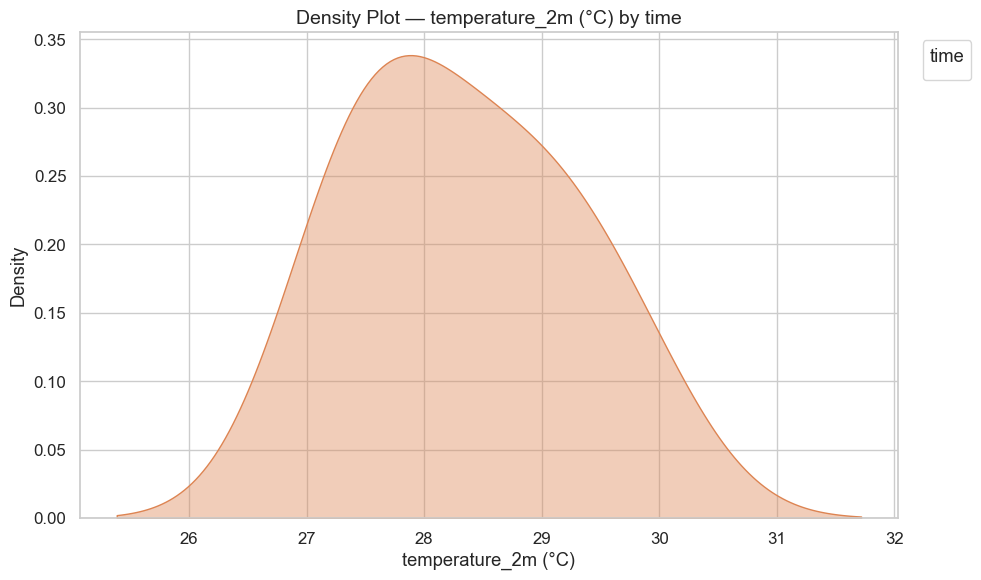

C:\Users\huynh\AppData\Local\Temp\ipykernel_14572\407724775.py:61: UserWarning: The palette list has more values (8) than needed (2), which may not be intended.
  sns.histplot(
C:\Users\huynh\AppData\Local\Temp\ipykernel_14572\407724775.py:75: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=cat_col, bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True)


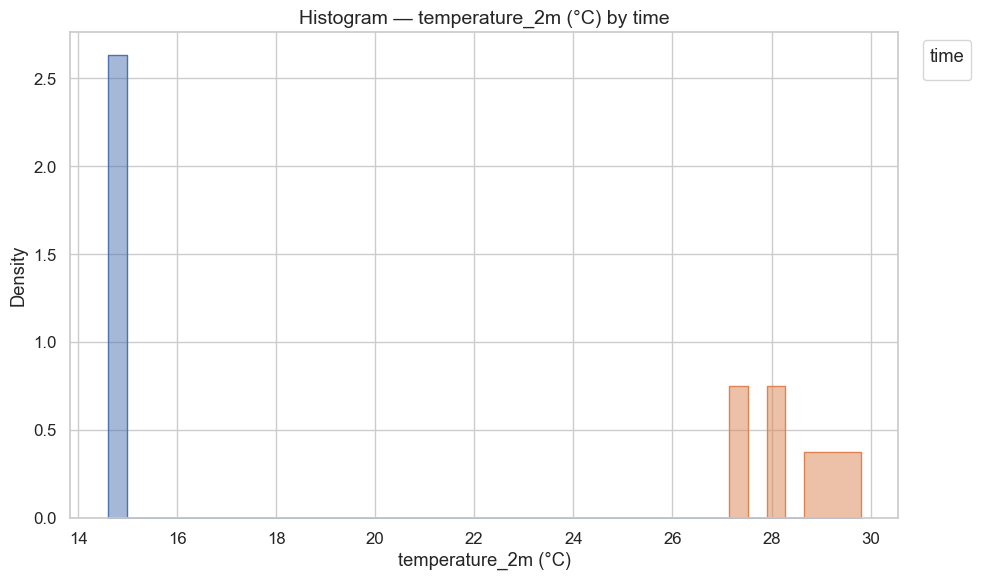

C:\Users\huynh\AppData\Local\Temp\ipykernel_14572\407724775.py:83: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\huynh\AppData\Local\Temp\ipykernel_14572\407724775.py:83: UserWarning: The palette list has more values (8) than needed (2), which may not be intended.
  sns.boxplot(


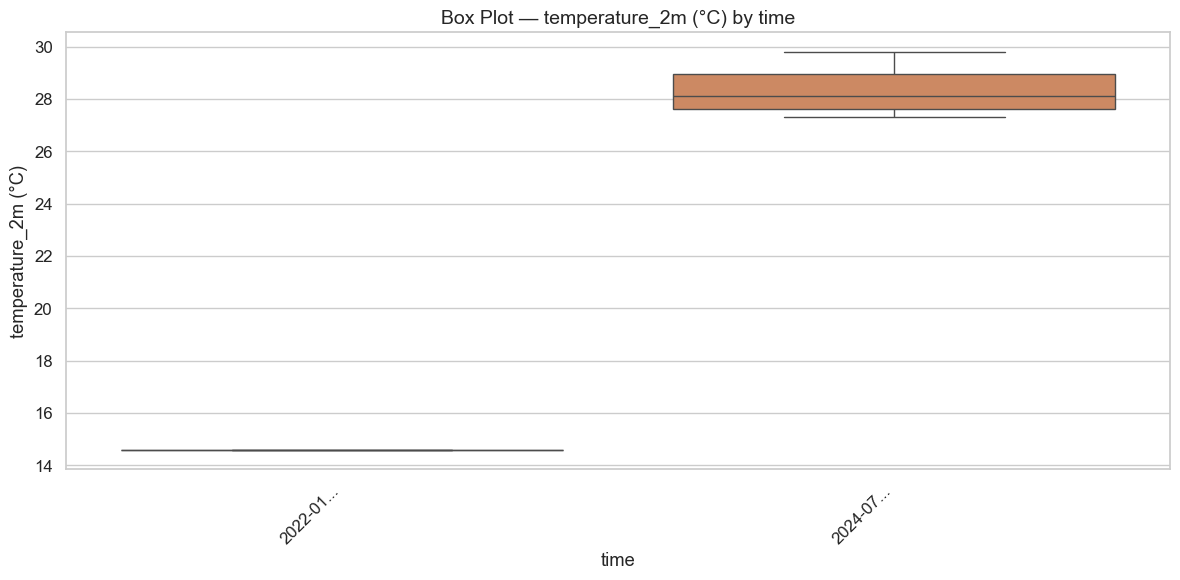

C:\Users\huynh\AppData\Local\Temp\ipykernel_14572\407724775.py:41: UserWarning: The palette list has more values (8) than needed (2), which may not be intended.
  sns.kdeplot(



📊 Vẽ biểu đồ cho cặp: (time, relative_humidity_2m (%))


C:\Users\huynh\AppData\Local\Temp\ipykernel_14572\407724775.py:41: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
C:\Users\huynh\AppData\Local\Temp\ipykernel_14572\407724775.py:53: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=cat_col, bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True)


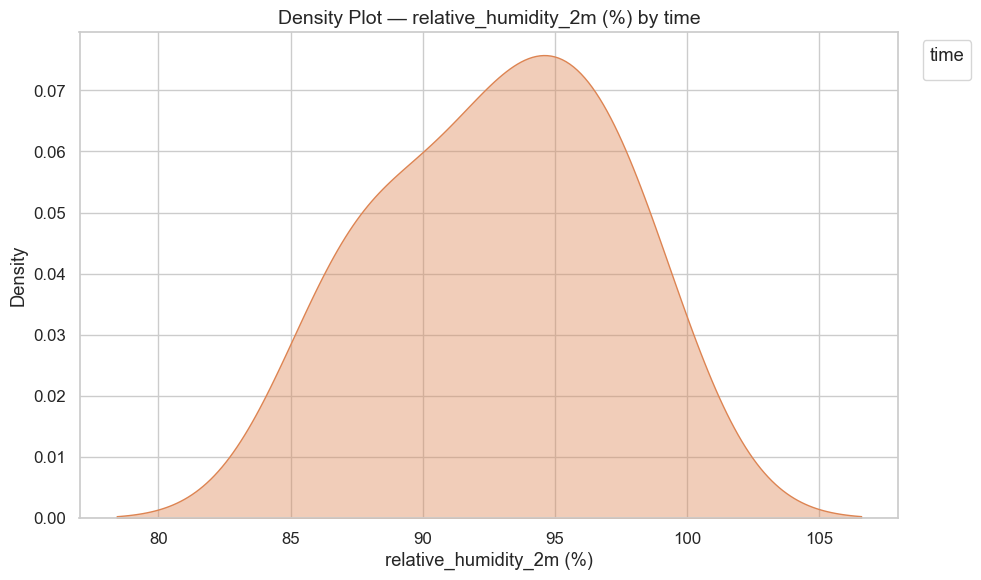

C:\Users\huynh\AppData\Local\Temp\ipykernel_14572\407724775.py:61: UserWarning: The palette list has more values (8) than needed (2), which may not be intended.
  sns.histplot(
C:\Users\huynh\AppData\Local\Temp\ipykernel_14572\407724775.py:75: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=cat_col, bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True)


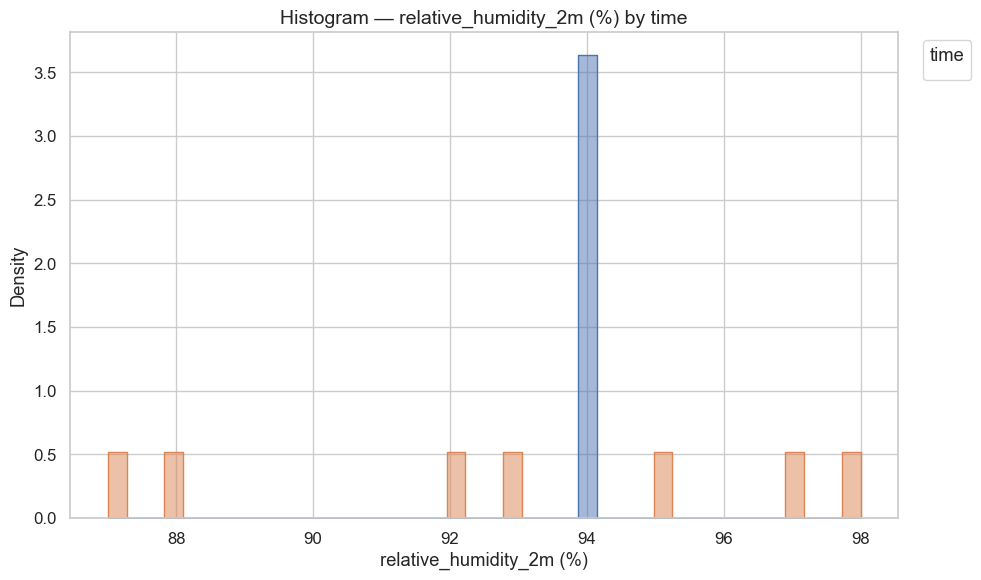

C:\Users\huynh\AppData\Local\Temp\ipykernel_14572\407724775.py:83: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\huynh\AppData\Local\Temp\ipykernel_14572\407724775.py:83: UserWarning: The palette list has more values (8) than needed (2), which may not be intended.
  sns.boxplot(


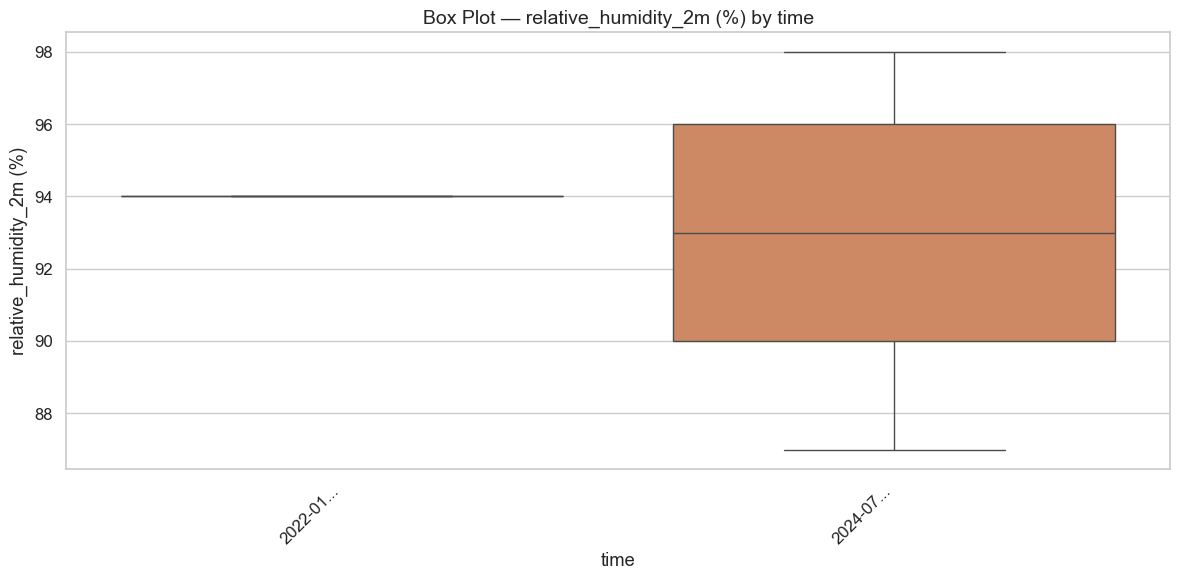

C:\Users\huynh\AppData\Local\Temp\ipykernel_14572\407724775.py:41: UserWarning: The palette list has more values (8) than needed (2), which may not be intended.
  sns.kdeplot(
C:\Users\huynh\AppData\Local\Temp\ipykernel_14572\407724775.py:41: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
C:\Users\huynh\AppData\Local\Temp\ipykernel_14572\407724775.py:53: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=cat_col, bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True)



📊 Vẽ biểu đồ cho cặp: (time, precipitation (mm))


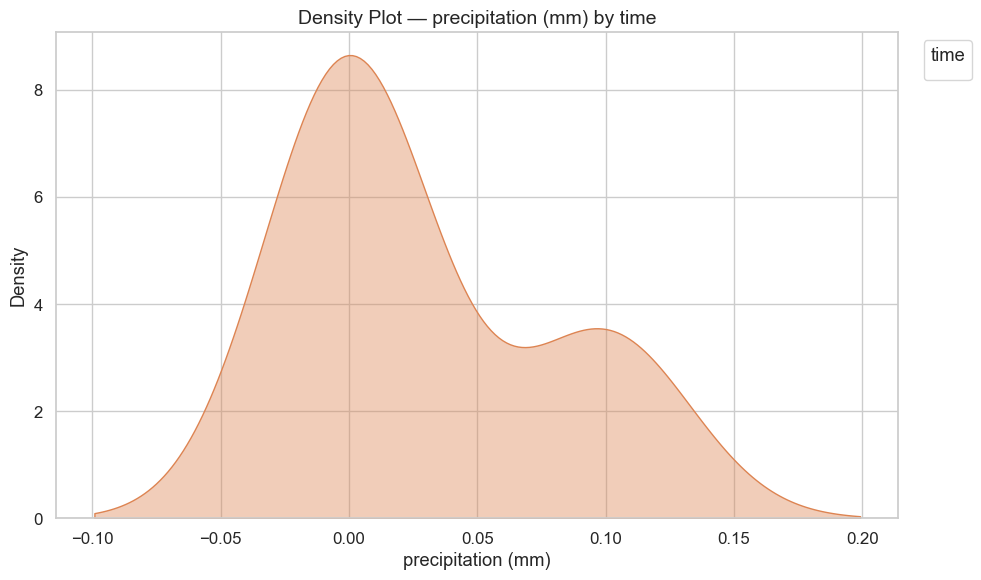

C:\Users\huynh\AppData\Local\Temp\ipykernel_14572\407724775.py:61: UserWarning: The palette list has more values (8) than needed (2), which may not be intended.
  sns.histplot(
C:\Users\huynh\AppData\Local\Temp\ipykernel_14572\407724775.py:75: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=cat_col, bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True)


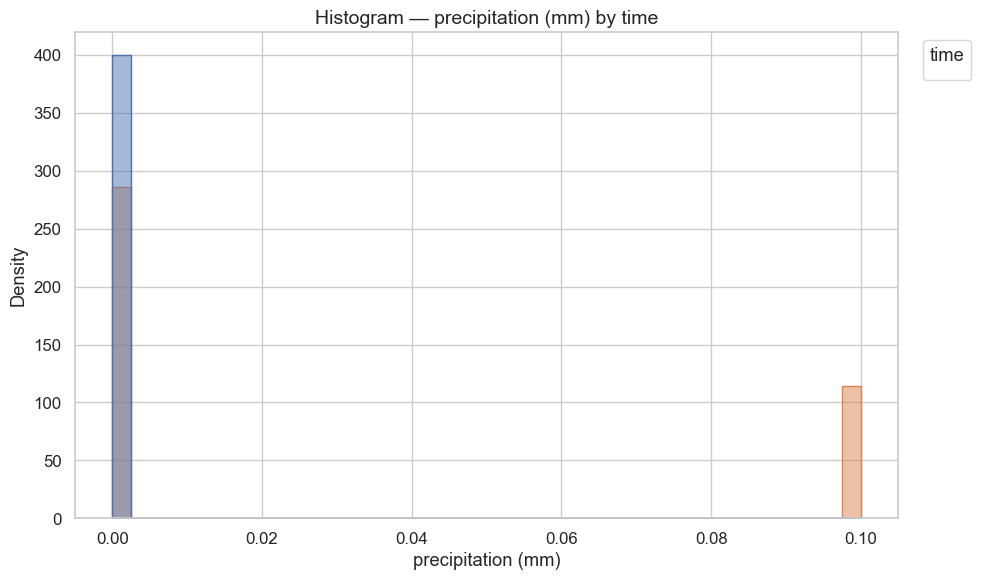

C:\Users\huynh\AppData\Local\Temp\ipykernel_14572\407724775.py:83: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\huynh\AppData\Local\Temp\ipykernel_14572\407724775.py:83: UserWarning: The palette list has more values (8) than needed (2), which may not be intended.
  sns.boxplot(


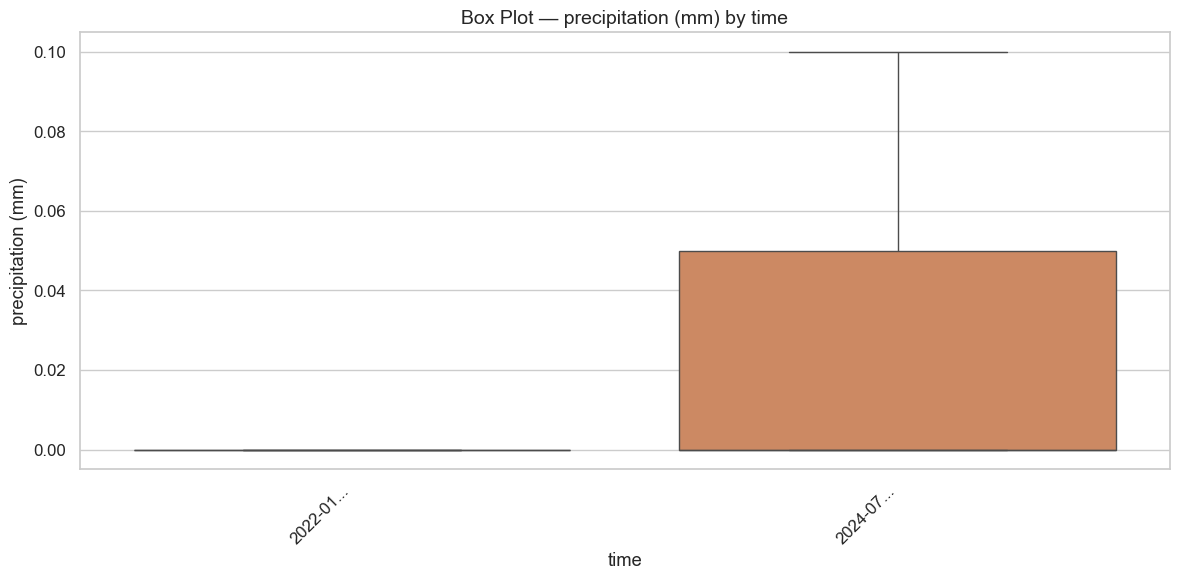

C:\Users\huynh\AppData\Local\Temp\ipykernel_14572\407724775.py:41: UserWarning: The palette list has more values (8) than needed (2), which may not be intended.
  sns.kdeplot(
C:\Users\huynh\AppData\Local\Temp\ipykernel_14572\407724775.py:41: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
C:\Users\huynh\AppData\Local\Temp\ipykernel_14572\407724775.py:53: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=cat_col, bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True)



📊 Vẽ biểu đồ cho cặp: (time, wind_speed_10m (km/h))
[⚠️] Thiếu cột time hoặc wind_speed_10m (km/h)

📊 Vẽ biểu đồ cho cặp: (time, cloud_cover (%))


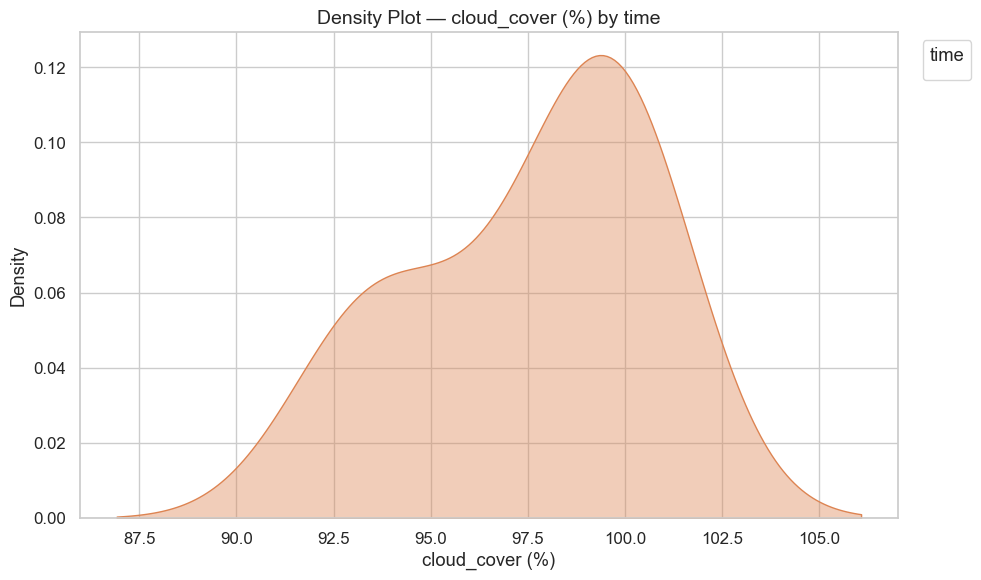

C:\Users\huynh\AppData\Local\Temp\ipykernel_14572\407724775.py:61: UserWarning: The palette list has more values (8) than needed (2), which may not be intended.
  sns.histplot(
C:\Users\huynh\AppData\Local\Temp\ipykernel_14572\407724775.py:75: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=cat_col, bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True)


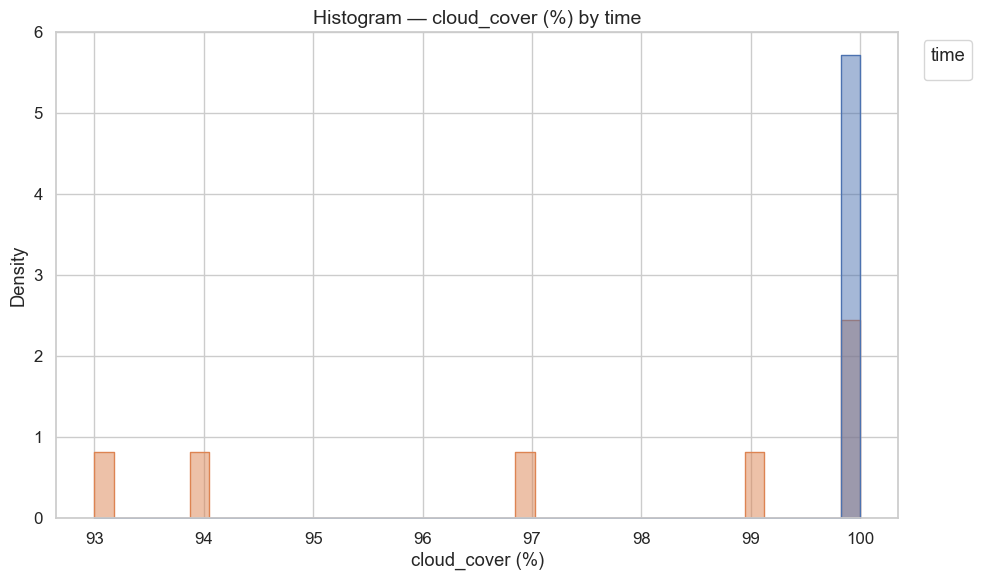

C:\Users\huynh\AppData\Local\Temp\ipykernel_14572\407724775.py:83: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\huynh\AppData\Local\Temp\ipykernel_14572\407724775.py:83: UserWarning: The palette list has more values (8) than needed (2), which may not be intended.
  sns.boxplot(


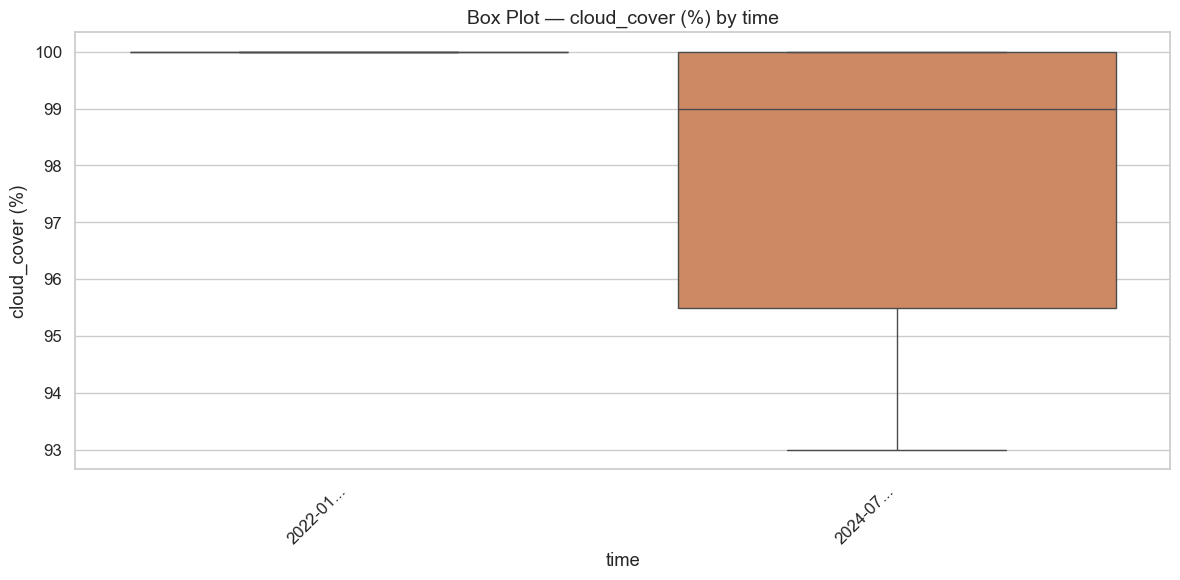

C:\Users\huynh\AppData\Local\Temp\ipykernel_14572\407724775.py:41: UserWarning: The palette list has more values (8) than needed (2), which may not be intended.
  sns.kdeplot(
C:\Users\huynh\AppData\Local\Temp\ipykernel_14572\407724775.py:41: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
C:\Users\huynh\AppData\Local\Temp\ipykernel_14572\407724775.py:53: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=cat_col, bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True)



📊 Vẽ biểu đồ cho cặp: (time, rain (mm))


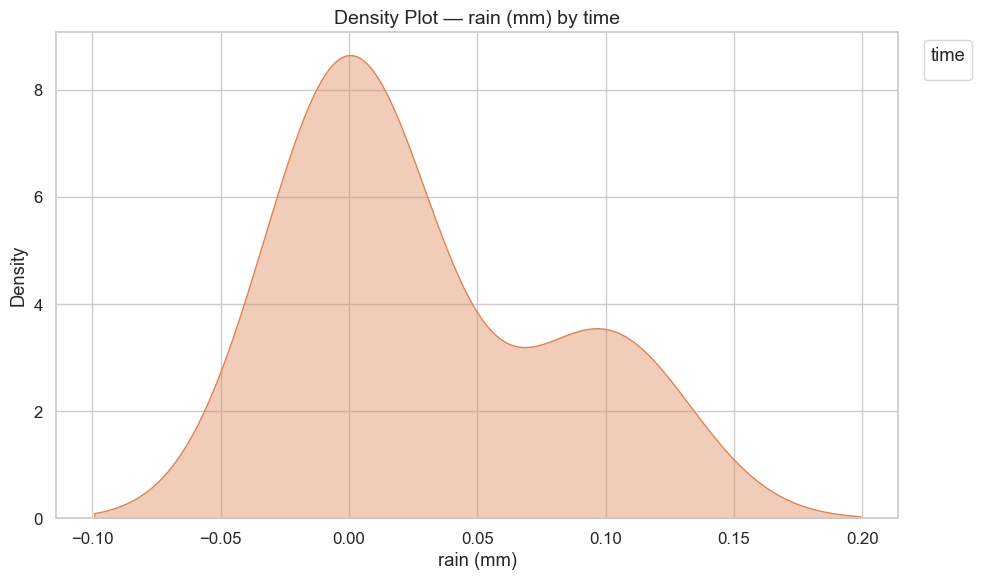

C:\Users\huynh\AppData\Local\Temp\ipykernel_14572\407724775.py:61: UserWarning: The palette list has more values (8) than needed (2), which may not be intended.
  sns.histplot(
C:\Users\huynh\AppData\Local\Temp\ipykernel_14572\407724775.py:75: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=cat_col, bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True)


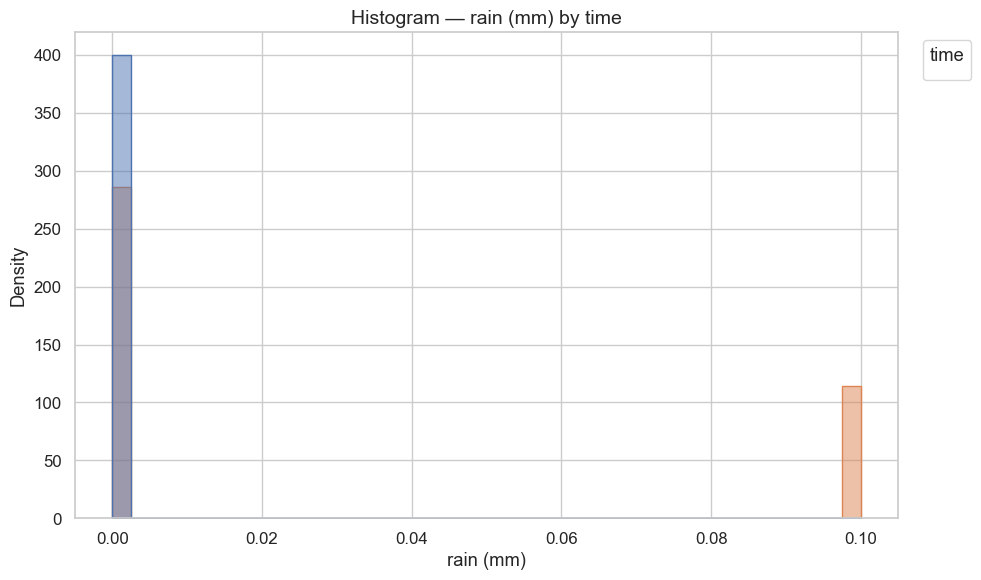

C:\Users\huynh\AppData\Local\Temp\ipykernel_14572\407724775.py:83: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\huynh\AppData\Local\Temp\ipykernel_14572\407724775.py:83: UserWarning: The palette list has more values (8) than needed (2), which may not be intended.
  sns.boxplot(


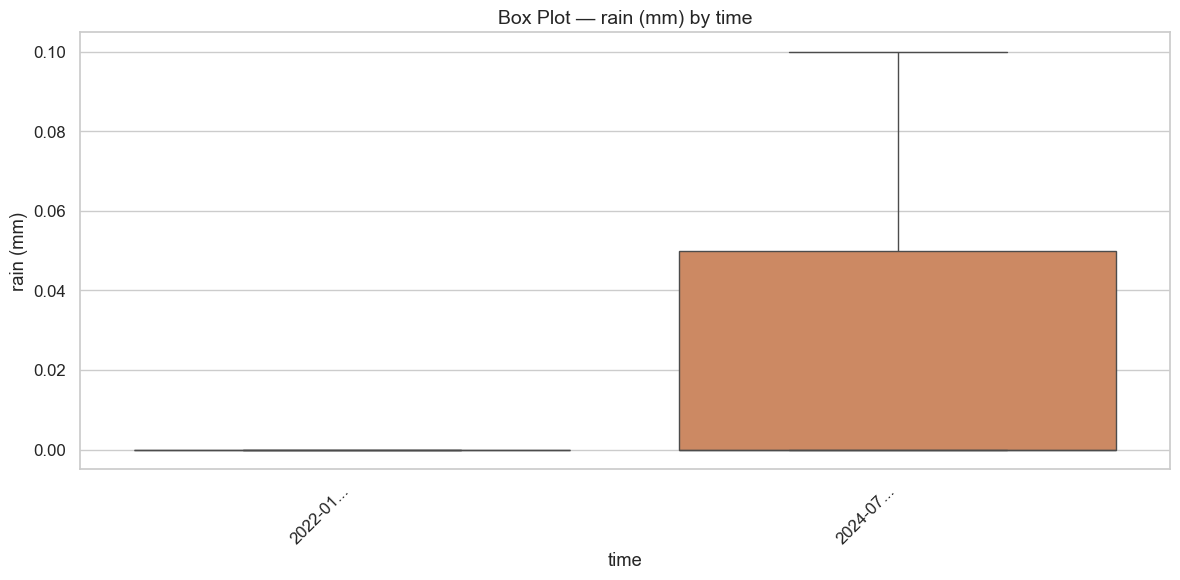

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid", font_scale=1.1)

def truncate_label(s, max_len=10):
    """Rút ngắn chuỗi để hiển thị nhãn đẹp hơn."""
    if s is None:
        return ""
    s = str(s)
    return s if len(s) <= max_len else s[:max_len-3] + "..."

def plot_numeric_category(df, cat_col, num_col, top_k=8):
    """
    Vẽ các biểu đồ Density, Histogram, Box Plot cho 1 cặp (category_col, numeric_col) dùng pandas.
    """
    # --- Chuẩn bị dữ liệu ---
    if cat_col not in df.columns or num_col not in df.columns:
        print(f"[⚠️] Thiếu cột {cat_col} hoặc {num_col}")
        return
    
    df_plot = df[[cat_col, num_col]].dropna()
    
    # Nếu dữ liệu trống thì bỏ qua
    if df_plot.empty:
        print(f"[⚠️] Không có dữ liệu hợp lệ cho ({cat_col}, {num_col})")
        return

    # Lấy top category phổ biến nhất
    top_cats = df_plot[cat_col].value_counts().nlargest(top_k).index
    df_top = df_plot[df_plot[cat_col].isin(top_cats)].copy()
    df_top[cat_col] = df_top[cat_col].apply(lambda x: truncate_label(x, max_len=10))

    palette = sns.color_palette(n_colors=len(top_cats))

    # ===============================
    # 1️⃣ DENSITY PLOT
    # ===============================
    plt.figure(figsize=(10, 6))
    sns.kdeplot(
        data=df_top,
        x=num_col,
        hue=cat_col,
        common_norm=False,
        fill=True,
        alpha=0.4,
        palette=palette
    )
    plt.title(f"Density Plot — {num_col} by {cat_col}", fontsize=14)
    plt.xlabel(num_col)
    plt.ylabel("Density")
    plt.legend(title=cat_col, bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True)
    plt.tight_layout()
    plt.show()

    # ===============================
    # 2️⃣ HISTOGRAM
    # ===============================
    plt.figure(figsize=(10, 6))
    sns.histplot(
        data=df_top,
        x=num_col,
        hue=cat_col,
        element="step",
        stat="density",
        common_norm=False,
        bins=40,
        alpha=0.5,
        palette=palette
    )
    plt.title(f"Histogram — {num_col} by {cat_col}", fontsize=14)
    plt.xlabel(num_col)
    plt.ylabel("Density")
    plt.legend(title=cat_col, bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True)
    plt.tight_layout()
    plt.show()

    # ===============================
    # 3️⃣ BOX PLOT
    # ===============================
    plt.figure(figsize=(12, 6))
    sns.boxplot(
        data=df_top,
        x=cat_col,
        y=num_col,
        palette=palette,
        showfliers=False
    )
    plt.title(f"Box Plot — {num_col} by {cat_col}", fontsize=14)
    plt.xlabel(cat_col)
    plt.ylabel(num_col)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# ===================================================
# 🔹 Gọi hàm cho toàn bộ cặp numeric–category
# ===================================================

numeric_cols = [
    'temperature_2m (°C)', 'relative_humidity_2m (%)', 'precipitation (mm)',
    'wind_speed_10m (km/h)', 'cloud_cover (%)', 'rain (mm)', 
]
category_cols = ['time']

print("🔢 Numeric columns:", numeric_cols)
print("🏷️ Category columns:", category_cols)

# Vẽ cho mọi cặp có dữ liệu
for cat_col in category_cols:
    for num_col in numeric_cols:
        print(f"\n📊 Vẽ biểu đồ cho cặp: ({cat_col}, {num_col})")
        plot_numeric_category(df, cat_col, num_col)
